In [1]:
import pandas as pd
import re
import string
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import emoji

# Télécharger les stopwords NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Déclaration du stemmer
stemmer = PorterStemmer()

# Dictionnaire des chat words à remplacer
chat_words_map_dict = {
    "u": "you",
    "r": "are",
    "ur": "your",
    "thx": "thanks",
    # Ajoutez d'autres termes de chat ici
}

# 1. Minuscule
def to_lowercase(text):
    return text.lower()

# 2. Supprimer les espaces blancs supplémentaires
def remove_extra_whitespaces(text):
    return re.sub(r'\s+', ' ', text).strip()

# 3. Supprimer les balises HTML
def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()

# 4. Supprimer les URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

# 5. Supprimer la ponctuation
def remove_punctuations(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# 6. Gérer les mots de chat
def handle_chat_words(text):
    tokens = text.split()
    return ' '.join([chat_words_map_dict.get(word.lower(), word) for word in tokens])

# 7. Supprimer les stopwords
def remove_stopwords(text):
    tokens = text.split()
    return ' '.join([word for word in tokens if word.lower() not in stop_words])

# 8. Supprimer les émojis
def remove_emojis(text):
    return emoji.get_emoji_regexp().sub(u'', text)

# 9. Appliquer le stemming
def apply_stemming(text):
    tokens = text.split()
    return ' '.join([stemmer.stem(word) for word in tokens])

# Fonction de prétraitement globale
def preprocess_text(text):
    text = to_lowercase(text)
    text = remove_extra_whitespaces(text)
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = remove_punctuations(text)
    text = handle_chat_words(text)
    text = remove_stopwords(text)
    text = remove_emojis(text)
    text = apply_stemming(text)
    return text

# Charger et prétraiter les fichiers CSV
def preprocess_dataset(file_path, output_path):
    # Charger le fichier CSV
    data = pd.read_csv(file_path)

    # Appliquer le prétraitement sur la colonne 'dialog'
    data['dialog'] = data['dialog'].apply(preprocess_text)

    # Sauvegarder le fichier nettoyé
    data.to_csv(output_path, index=False)

# Fichiers CSV à prétraiter
files = {
    "train.csv": "train_cleaned.csv",
    "validation.csv": "validation_cleaned.csv",
    "test.csv": "test_cleaned.csv"
}

# Appliquer le prétraitement sur chaque fichier
for input_file, output_file in files.items():
    preprocess_dataset(input_file, output_file)

print("Prétraitement terminé et fichiers nettoyés sauvegardés.")


ModuleNotFoundError: No module named 'emoji'

In [40]:
df = pd.read_csv('validation.csv')
df.head()

,dialog,act,emotion
0,"['Good morning , sir . Is there a bank near he...",[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,['Good afternoon . This is Michelle Li speakin...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,['What qualifications should a reporter have ?...,[2 1 2 1],[0 0 0 0]
3,"['Hi , good morning , Miss ? what can I help y...",[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,"[""Excuse me , ma'am . Can you tell me where th...",[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


In [3]:
df2 = pd.read_csv('test.csv')
df3 = pd.read_csv('validation.csv')


In [41]:
# Shape Of Data 
print(f'The Shape Of Data Is : {df.shape}')

The Shape Of Data Is : (1000, 3)


In [42]:
# Null Values 
df.isnull().sum()

dialog     0
act        0
emotion    0
dtype: int64

In [43]:
# Duplicates
df.duplicated().sum()

0

In [44]:
# Rename Columns 
df.rename(columns={'dialog': 'Dialog', 'emotion': 'Emotion'}, inplace=True)

# Head Of Data
df.head()

,Dialog,act,Emotion
0,"['Good morning , sir . Is there a bank near he...",[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,['Good afternoon . This is Michelle Li speakin...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,['What qualifications should a reporter have ?...,[2 1 2 1],[0 0 0 0]
3,"['Hi , good morning , Miss ? what can I help y...",[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,"[""Excuse me , ma'am . Can you tell me where th...",[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


C:\Users\Naj La\AppData\Local\Temp\ipykernel_7984\3664099421.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")


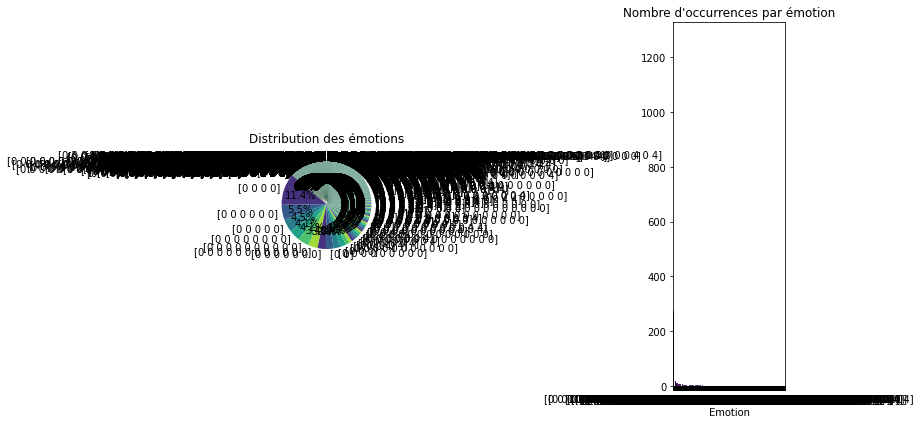

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Compter les occurrences de chaque émotion
count = df['Emotion'].value_counts()

# Créer une figure avec deux sous-graphes
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Définir une palette de couleurs
palette = sns.color_palette("viridis")
sns.set_palette(palette)

# 1. Graphique à secteurs
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140, colors=palette)
axs[0].set_title('Distribution des émotions')

# 2. Graphique à barres
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette="viridis")
axs[1].set_title('Nombre d\'occurrences par émotion')

# Ajuster la disposition pour éviter le chevauchement
plt.tight_layout()

# Afficher le graphique
plt.show()


In [31]:
# Import Basis Needed Libaries 
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources (uncomment the following line if not already downloaded)?
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Naj
[nltk_data]     La\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Naj
[nltk_data]     La\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [45]:
# Step 1: Remove URLs
df['Dialog'] = df['Dialog'].str.replace(r'http\S+', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                              Dialog  \
0  ['Good morning , sir . Is there a bank near he...   
1  ['Good afternoon . This is Michelle Li speakin...   
2  ['What qualifications should a reporter have ?...   
3  ['Hi , good morning , Miss ? what can I help y...   
4  ["Excuse me , ma'am . Can you tell me where th...   

                                 act                            Emotion  
0                    [2 1 3 2 1 2 1]                    [0 0 0 0 0 0 0]  
1              [2 1 1 1 1 2 3 2 3 4]              [0 0 0 0 0 0 0 0 0 0]  
2                          [2 1 2 1]                          [0 0 0 0]  
3  [2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4]  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]  
4                  [3 4 2 1 2 1 1 1]                  [0 0 0 0 0 0 4 4]  


In [46]:
# Step 2: Remove special characters and punctuation
df['Dialog'] = df['Dialog'].str.replace(r'[^\w\s]', '', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                              Dialog  \
0  Good morning  sir  Is there a bank near here  ...   
1  Good afternoon  This is Michelle Li speaking  ...   
2  What qualifications should a reporter have  \n...   
3  Hi  good morning  Miss  what can I help you wi...   
4  Excuse me  maam  Can you tell me where the nea...   

                                 act                            Emotion  
0                    [2 1 3 2 1 2 1]                    [0 0 0 0 0 0 0]  
1              [2 1 1 1 1 2 3 2 3 4]              [0 0 0 0 0 0 0 0 0 0]  
2                          [2 1 2 1]                          [0 0 0 0]  
3  [2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4]  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]  
4                  [3 4 2 1 2 1 1 1]                  [0 0 0 0 0 0 4 4]  


In [47]:
# Step 3: Remove extra whitespaces
df['Dialog'] = df['Dialog'].str.replace(r'\s+', ' ', regex=True)

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                              Dialog  \
0  Good morning sir Is there a bank near here The...   
1  Good afternoon This is Michelle Li speaking ca...   
2  What qualifications should a reporter have As ...   
3  Hi good morning Miss what can I help you with ...   
4  Excuse me maam Can you tell me where the neare...   

                                 act                            Emotion  
0                    [2 1 3 2 1 2 1]                    [0 0 0 0 0 0 0]  
1              [2 1 1 1 1 2 3 2 3 4]              [0 0 0 0 0 0 0 0 0 0]  
2                          [2 1 2 1]                          [0 0 0 0]  
3  [2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4]  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]  
4                  [3 4 2 1 2 1 1 1]                  [0 0 0 0 0 0 4 4]  


In [48]:
# Step : 4 Remove numeric values
df['Dialog'] = df['Dialog'].str.replace(r'\d+', '', regex=True)

# Head
df.head()

,Dialog,act,Emotion
0,Good morning sir Is there a bank near here The...,[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,Good afternoon This is Michelle Li speaking ca...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,What qualifications should a reporter have As ...,[2 1 2 1],[0 0 0 0]
3,Hi good morning Miss what can I help you with ...,[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,Excuse me maam Can you tell me where the neare...,[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


In [49]:
# Step 6: Lowercasing
df['Dialog'] = df['Dialog'].str.lower()

# Display the first few rows of the DataFrame to verify the changes
print(df.head())

                                              Dialog  \
0  good morning sir is there a bank near here the...   
1  good afternoon this is michelle li speaking ca...   
2  what qualifications should a reporter have as ...   
3  hi good morning miss what can i help you with ...   
4  excuse me maam can you tell me where the neare...   

                                 act                            Emotion  
0                    [2 1 3 2 1 2 1]                    [0 0 0 0 0 0 0]  
1              [2 1 1 1 1 2 3 2 3 4]              [0 0 0 0 0 0 0 0 0 0]  
2                          [2 1 2 1]                          [0 0 0 0]  
3  [2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4]  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]  
4                  [3 4 2 1 2 1 1 1]                  [0 0 0 0 0 0 4 4]  


In [50]:
# Step 8: Remove stop words
stop = stopwords.words('english')
df["Dialog"] = df['Dialog'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,Dialog,act,Emotion
0,good morning sir bank near one blocks away wel...,[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,good afternoon michelle li speaking calling be...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,qualifications reporter reporter must acute in...,[2 1 2 1],[0 0 0 0]
3,hi good morning miss help good morning id like...,[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,excuse maam tell nearest postoffice course go ...,[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


In [51]:
# Step : 9 Remove non-alphanumeric characters from the 'Text' column
df['Dialog'] = df['Dialog'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Display the first few rows of the DataFrame to verify the changes
df.head()

,Dialog,act,Emotion
0,good morning sir bank near one blocks away wel...,[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,good afternoon michelle li speaking calling be...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,qualifications reporter reporter must acute in...,[2 1 2 1],[0 0 0 0]
3,hi good morning miss help good morning id like...,[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,excuse maam tell nearest postoffice course go ...,[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


In [52]:
  # Sauvegarder le fichier nettoyé
df.to_csv('dailydiolog_validation.csv', index=False)

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# from textacy import preprocessing
from nltk.stem.snowball import SnowballStemmer
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import re

In [4]:
import ast
# Charger les fichiers CSV
train_df = pd.read_csv('dailydiolog_train.csv')
validation_df = pd.read_csv('dailydiolog_validation.csv')
test_df = pd.read_csv('dailydiolog_test.csv')

# Afficher les premières lignes de chaque DataFrame pour vérifier le contenu
print("Train DataFrame:")
print(train_df.head())
print("\nValidation DataFrame:")
print(validation_df.head())
print("\nTest DataFrame:")
print(test_df.head())

# Concaténer tous les DataFrames en un seul
full_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

# Nettoyer la colonne 'Emotion' et convertir en liste
full_df['Emotion'] = full_df['Emotion'].str.replace(' ', ',')  # Remplacer les espaces par des virgules
full_df['Emotion'] = full_df['Emotion'].apply(ast.literal_eval)  # Convertir en liste

# Extraire les dialogues et les émotions
X = full_df['Dialog']
y = full_df['Emotion'].apply(lambda x: x[0])  # Prendre la première émotion pour chaque dialogue

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Afficher les formes des ensembles d'entraînement et de test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Train DataFrame:
                                              Dialog                    act  \
0  say jim going beers dinner know tempting reall...  [3 4 2 2 2 3 4 1 3 4]   
1  pushups course piece cake believe pushups minu...          [2 1 2 2 1 1]   
2  study radio listen background music difference...            [2 1 2 1 1]   
3  right right soon terrified watched fall wire d...              [2 1 1 1]   
4  hey john nice skates new yeah got started play...    [2 1 2 1 1 2 1 3 4]   

                 Emotion  
0  [0 0 0 0 0 0 4 4 4 4]  
1          [0 0 6 0 0 0]  
2            [0 0 0 0 0]  
3              [0 0 0 0]  
4    [0 0 0 0 0 6 0 6 0]  

Validation DataFrame:
                                              Dialog  \
0  good morning sir bank near one blocks away wel...   
1  good afternoon michelle li speaking calling be...   
2  qualifications reporter reporter must acute in...   
3  hi good morning miss help good morning id like...   
4  excuse maam tell nearest postoffice cour

In [5]:
# Tokenize the text data
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)
tokenizer.fit_on_texts(X_test)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [6]:
# Max Len in X_train_sequences
maxlen = max(len(tokens) for tokens in X_train_sequences)
print("Maximum sequence length (maxlen):", maxlen)

Maximum sequence length (maxlen): 271


In [7]:
# Perform padding on X_train and X_test sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post',)
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post')

# Print the padded sequences for X_train and X_test
print("X_train_padded:")
print(X_train_padded)
print("\nX_test_padded:")
print(X_test_padded)

X_train_padded:
[[  425   292    15 ...     0     0     0]
 [   86    21   269 ...     0     0     0]
 [  134    24   640 ...     0     0     0]
 ...
 [   56  4028 20060 ...     0     0     0]
 [   44    57    57 ...     0     0     0]
 [    4    24 10645 ...     0     0     0]]

X_test_padded:
[[  123    49     3 ...     0     0     0]
 [   23     8   240 ...     0     0     0]
 [  705    92   119 ...     0     0     0]
 ...
 [   30    22  2008 ...     0     0     0]
 [    1   794    94 ...     0     0     0]
 [  169 13668   827 ...     0     0     0]]


In [8]:
# Embedding Input Size / Vocabulary Size 
input_Size = np.max(X_train_padded) + 1
input_Size

20064

In [11]:
from keras.preprocessing import sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import re
# Define the model
model = Sequential()

# Add embedding layer
model.add(Embedding(input_dim=input_Size, output_dim=50, input_length=maxlen))

# Dropout
model.add(Dropout(0.5))

# Add Bidirectional LSTM layer
model.add(Bidirectional(GRU(120, return_sequences=True)))
model.add(Bidirectional(GRU(64, return_sequences=True)))

#Batch Normalization
model.add(BatchNormalization())

# Add Bidirectional GRU layer
model.add(Bidirectional(GRU(64)))

# Add output layer
model.add(Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 271, 50)           1003200   
                                                                 
 dropout_1 (Dropout)         (None, 271, 50)           0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 271, 240)         123840    
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 271, 128)         117504    
 nal)                                                            
                                                                 
 batch_normalization_1 (Batc  (None, 271, 128)         512       
 hNormalization)                                                 
                                                      

In [12]:
# Model Train 
history = model.fit(X_train_padded, y_train, epochs=5, batch_size=1500, validation_data=(X_test_padded, y_test))

Epoch 1/5
1/7 [===>..........................] - ETA: 3:26:05 - loss: 2.2947 - accuracy: 0.0240

In [ ]:
# Evaluate Test Data 
model.evaluate(X_test_padded, y_test)

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Charger les données
train_data = pd.read_csv('dailydiolog_train.csv')
test_data = pd.read_csv('dailydiolog_test.csv')
validation_data = pd.read_csv('dailydiolog_validation.csv')

# Combiner les données
all_data = pd.concat([train_data, test_data, validation_data])

# 2. Prétraitement du texte et des labels
MAX_VOCAB_SIZE = 5000
MAX_SEQUENCE_LENGTH = 100

# Tokenizer pour transformer les textes en séquences d'index
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(all_data['Dialog'])
sequences = tokenizer.texts_to_sequences(all_data['Dialog'])

# Padding des séquences pour avoir la même longueur
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Encodage des labels d'émotion
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(all_data['Emotion'])

# Conversion en catégories (pour softmax)
y = tf.keras.utils.to_categorical(y, num_classes=len(label_encoder.classes_))

# 3. Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Construction du modèle LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Entraînement du modèle
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# 6. Évaluation sur les données de test
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')
model.save('emotion_recognition_lstm_model.h5')


Epoch 1/10
263/263 [==============================] - 47s 154ms/step - loss: 5.9699 - accuracy: 0.1126 - val_loss: 5.8541 - val_accuracy: 0.1091
Epoch 2/10
263/263 [==============================] - 45s 171ms/step - loss: 5.3947 - accuracy: 0.1152 - val_loss: 5.7920 - val_accuracy: 0.1110
Epoch 3/10
263/263 [==============================] - 48s 181ms/step - loss: 5.0996 - accuracy: 0.1342 - val_loss: 5.5964 - val_accuracy: 0.1424
Epoch 4/10
263/263 [==============================] - 45s 173ms/step - loss: 4.7816 - accuracy: 0.1531 - val_loss: 5.6384 - val_accuracy: 0.1472
Epoch 5/10
263/263 [==============================] - 50s 190ms/step - loss: 5.0622 - accuracy: 0.1281 - val_loss: 5.8772 - val_accuracy: 0.1320
Epoch 6/10
263/263 [==============================] - 43s 165ms/step - loss: 4.6992 - accuracy: 0.1485 - val_loss: 5.8136 - val_accuracy: 0.1463
Epoch 7/10
263/263 [==============================] - 44s 166ms/step - loss: 4.4666 - accuracy: 0.1670 - val_loss: 5.9174 - val_ac

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Charger le modèle pré-entraîné
loaded_model = tf.keras.models.load_model('emotion_recognition_lstm_model.h5')

# Exemple de texte à tester
new_text = ["I am very happy to hear that you are coming to the party!"]

# Prétraiter le texte comme vous l'avez fait pour l'entraînement
# Tokenization du texte (le tokenizer doit être le même que celui utilisé pour entraîner le modèle)
sequences = tokenizer.texts_to_sequences(new_text)

# Padding des séquences pour correspondre à la longueur d'entrée du modèle
MAX_SEQUENCE_LENGTH = 100  # Assurez-vous que cela correspond à ce que vous avez utilisé lors de l'entraînement
padded_sequence = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Faire la prédiction
predicted_probabilities = loaded_model.predict(padded_sequence)

# Obtenir l'émotion prédite (l'indice avec la probabilité la plus élevée)
predicted_emotion_index = np.argmax(predicted_probabilities, axis=1)

# Traduire l'indice de l'émotion prédite en étiquette
predicted_emotion = label_encoder.inverse_transform(predicted_emotion_index)

# Afficher le résultat
print(f"Le texte : {new_text[0]}")
print(f"Émotion prédite : {predicted_emotion[0]}")


1/1 [==============================] - 1s 989ms/step
Le texte : I am very happy to hear that you are coming to the party!
Émotion prédite : [0 0]


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Charger le modèle pré-entraîné
loaded_model = tf.keras.models.load_model('emotion_recognition_lstm_model.h5')

# Exemple de texte à tester
new_text = ["I am very happy to hear that you are coming to the party!"]

# Prétraiter le texte (tokenizer doit être celui utilisé pendant l'entraînement)
sequences = tokenizer.texts_to_sequences(new_text)

# Padding des séquences pour correspondre à la longueur d'entrée du modèle
MAX_SEQUENCE_LENGTH = 100  # Doit être le même que celui utilisé pendant l'entraînement
padded_sequence = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Faire la prédiction
predicted_probabilities = loaded_model.predict(padded_sequence)

# Obtenir l'indice de l'émotion prédite
predicted_emotion_index = np.argmax(predicted_probabilities, axis=1)

# Traduire l'indice de l'émotion en nom (utiliser l'encodeur de labels)
predicted_emotion = label_encoder.inverse_transform(predicted_emotion_index)

# Afficher l'émotion en lettre
print(f"Le texte : {new_text[0]}")
print(f"Émotion prédite : {predicted_emotion[0]}")


1/1 [==============================] - 1s 728ms/step
Le texte : I am very happy to hear that you are coming to the party!
Émotion prédite : [0 0]


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

# Charger le modèle pré-entraîné
loaded_model = tf.keras.models.load_model('emotion_recognition_lstm_model.h5')

# Charger le LabelEncoder sauvegardé
label_encoder = joblib.load('label_encoder.pkl')

# Exemple de texte à tester
new_text = ["I am very happy to hear that you are coming to the party!"]

# Tokenizer pour transformer le texte (utiliser le même tokenizer que lors de l'entraînement)
sequences = tokenizer.texts_to_sequences(new_text)

# Padding des séquences pour correspondre à la longueur d'entrée du modèle
MAX_SEQUENCE_LENGTH = 100  # Assurez-vous que c'est la même longueur utilisée à l'entraînement
padded_sequence = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Faire la prédiction
predicted_probabilities = loaded_model.predict(padded_sequence)

# Obtenir l'indice de l'émotion prédite
predicted_emotion_index = np.argmax(predicted_probabilities, axis=1)

# Traduire l'indice de l'émotion en lettres
predicted_emotion = label_encoder.inverse_transform(predicted_emotion_index)

# Afficher l'émotion prédite
print(f"Le texte : {new_text[0]}")
print(f"Émotion prédite : {predicted_emotion[0]}")


FileNotFoundError: [Errno 2] No such file or directory: 'label_encoder.pkl'

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import joblib

# 1. Charger les données
train_data = pd.read_csv('dailydiolog_train.csv')
test_data = pd.read_csv('dailydiolog_test.csv')
validation_data = pd.read_csv('dailydiolog_validation.csv')

# Combiner les données
all_data = pd.concat([train_data, test_data, validation_data])

# 2. Prétraitement du texte et des labels
MAX_VOCAB_SIZE = 5000
MAX_SEQUENCE_LENGTH = 100

# Tokenizer pour transformer les textes en séquences d'index
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(all_data['Dialog'])
sequences = tokenizer.texts_to_sequences(all_data['Dialog'])

# Padding des séquences pour avoir la même longueur
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Encodage des labels d'émotion
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(all_data['Emotion'])

# Sauvegarder le tokenizer et le label encoder pour une utilisation future
joblib.dump(tokenizer, 'tokenizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

# Conversion en catégories (pour softmax)
y = tf.keras.utils.to_categorical(y, num_classes=len(label_encoder.classes_))

# 3. Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Construction du modèle LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Entraînement du modèle
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# 6. Évaluation sur les données de test
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy}')

# 7. Sauvegarder le modèle entraîné
model.save('emotion_recognition_lstm_model.h5')


Epoch 1/10
263/263 [==============================] - 43s 151ms/step - loss: 5.9717 - accuracy: 0.1110 - val_loss: 5.8522 - val_accuracy: 0.1091
Epoch 2/10
263/263 [==============================] - 50s 189ms/step - loss: 5.3776 - accuracy: 0.1153 - val_loss: 5.7440 - val_accuracy: 0.1110
Epoch 3/10
263/263 [==============================] - 49s 187ms/step - loss: 5.0167 - accuracy: 0.1423 - val_loss: 5.6872 - val_accuracy: 0.1343
Epoch 4/10
263/263 [==============================] - 45s 171ms/step - loss: 4.7232 - accuracy: 0.1649 - val_loss: 5.6465 - val_accuracy: 0.1596
Epoch 5/10
263/263 [==============================] - 44s 167ms/step - loss: 4.4753 - accuracy: 0.1776 - val_loss: 5.7525 - val_accuracy: 0.1591
Epoch 6/10
263/263 [==============================] - 54s 204ms/step - loss: 4.2545 - accuracy: 0.1956 - val_loss: 5.9849 - val_accuracy: 0.1648
Epoch 7/10
263/263 [==============================] - 36s 135ms/step - loss: 4.0294 - accuracy: 0.2152 - val_loss: 6.0197 - val_ac

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

# Charger le modèle pré-entraîné
loaded_model = tf.keras.models.load_model('emotion_recognition_lstm_model.h5')

# Charger le LabelEncoder sauvegardé
label_encoder = joblib.load('label_encoder.pkl')

# Exemple de texte à tester
new_text = ["I am very happy to hear that you are coming to the party!"]

# Tokenizer pour transformer le texte (utiliser le même tokenizer que lors de l'entraînement)
sequences = tokenizer.texts_to_sequences(new_text)

# Padding des séquences pour correspondre à la longueur d'entrée du modèle
MAX_SEQUENCE_LENGTH = 100  # Assurez-vous que c'est la même longueur utilisée à l'entraînement
padded_sequence = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Faire la prédiction
predicted_probabilities = loaded_model.predict(padded_sequence)

# Obtenir l'indice de l'émotion prédite
predicted_emotion_index = np.argmax(predicted_probabilities, axis=1)

# Traduire l'indice de l'émotion en lettres
predicted_emotion = label_encoder.inverse_transform(predicted_emotion_index)

# Afficher l'émotion prédite
print(f"Le texte : {new_text[0]}")
print(f"Émotion prédite : {predicted_emotion[0]}")

1/1 [==============================] - 1s 694ms/step
Le texte : I am very happy to hear that you are coming to the party!
Émotion prédite : [4 4]
